<a href="https://colab.research.google.com/github/rishaan1402/Deathwish/blob/gh-pages/Tabular_Data_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rishaanrathore
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 721MB/s]

In [4]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchsummary import summary
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [45]:
data_df =pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [46]:
data_df.dropna(inplace=True)
data_df.drop(("id"),axis=1,inplace=True)
print(data_df.shape)

(18185, 11)


In [47]:
print(data_df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [48]:
original_df=data_df.copy()
for column in data_df.columns:
  data_df[column] =data_df[column]/data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [49]:
x= np.array(data_df.iloc[:,:-1])
y=np.array(data_df.iloc[:,-1])

In [50]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=.3)

In [51]:
x_test,x_val,y_test,y_val= train_test_split(x_test,y_test,test_size=.3)

In [52]:
print(x_train.shape)
print(x_test.shape)
print(x_val.shape)

(12729, 10)
(3819, 10)
(1637, 10)


In [53]:
class dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.Y = torch.tensor(Y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.Y[index]




In [54]:
training_data = dataset(x_train, y_train)
validation = dataset(x_val, y_val)
testing_data = dataset(x_test, y_test)

In [82]:
train_dataloader =DataLoader(training_data, batch_size= 32, shuffle= True)
validation_dataloader =DataLoader(validation, batch_size=  32 , shuffle= True)
testing_dataloader =DataLoader(testing_data, batch_size= 32, shuffle= True)

In [83]:
Hidden_Neurons=10
class Mymodel(nn.Module):
  def __init__(self):
    super(Mymodel, self).__init__()

    self.input_layer = nn.Linear(x.shape[1],Hidden_Neurons)
    self.linear=nn.Linear(Hidden_Neurons, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x= self.input_layer(x)
    x= self.linear(x)
    x= self.sigmoid(x)
    return x

model = Mymodel().to(device)

In [84]:
summary(model,(x.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [85]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(),lr=1e-3)

In [86]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot=[]
total_acc_validation_plot=[]

epochs=10
for epoch in range(epochs):
  total_acc_train = 0
  total_loss_train=0
  total_acc_val = 0
  total_loss_val=0

  for data in train_dataloader:
    input,labels = data

    prediction=model(input).squeeze(1)

    batch_loss = criterion(prediction, labels)

    total_loss_train+= batch_loss.item()

    acc= ((prediction).round()==labels).sum().item()

    total_acc_train+= acc

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      input,labels = data
      prediction=model(input).squeeze(1)
      batch_loss = criterion(prediction, labels)
      total_loss_val += batch_loss.item()
      acc= ((prediction).round()==labels).sum().item()
      total_acc_val += acc
  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round( total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100, 4))
  total_acc_validation_plot.append(round(total_acc_val/validation.__len__()*100, 4))

  print(f"Epoch no. {epoch+1} Train loss : {round(total_loss_train/1000,4)} Train Accuracy:{round(total_acc_train/training_data.__len__()*100,4)} Validation Loss : {round(total_loss_val/1000,4)} Validation Accuracy : {round(total_acc_val/validation.__len__()*100,4)} ")
  print("="*25)

Epoch no. 1 Train loss : 0.239 Train Accuracy:79.3778 Validation Loss : 0.0236 Validation Accuracy : 97.8009 
Epoch no. 2 Train loss : 0.1191 Train Accuracy:98.1303 Validation Loss : 0.0102 Validation Accuracy : 97.8619 
Epoch no. 3 Train loss : 0.0558 Train Accuracy:98.4288 Validation Loss : 0.0058 Validation Accuracy : 97.8009 
Epoch no. 4 Train loss : 0.0358 Train Accuracy:98.5152 Validation Loss : 0.0043 Validation Accuracy : 98.1063 
Epoch no. 5 Train loss : 0.0275 Train Accuracy:98.5309 Validation Loss : 0.0036 Validation Accuracy : 98.1063 
Epoch no. 6 Train loss : 0.0234 Train Accuracy:98.6095 Validation Loss : 0.0033 Validation Accuracy : 98.1674 
Epoch no. 7 Train loss : 0.0211 Train Accuracy:98.6645 Validation Loss : 0.0032 Validation Accuracy : 98.1674 
Epoch no. 8 Train loss : 0.0195 Train Accuracy:98.6566 Validation Loss : 0.0028 Validation Accuracy : 98.2896 
Epoch no. 9 Train loss : 0.0185 Train Accuracy:98.6802 Validation Loss : 0.0029 Validation Accuracy : 98.1063 
Ep

In [88]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader:
    inputs,labels = data
    prediction= model(inputs).squeeze(1)
    batch_loss_test = criterion(prediction , labels).item()
    total_loss_test +=batch_loss_test
    acc = ((prediction).round()==labels).sum().item()
    total_acc_test+=acc

  print("Accuracy ", round(total_acc_test/testing_data.__len__()*100,4))

Accuracy  98.7169


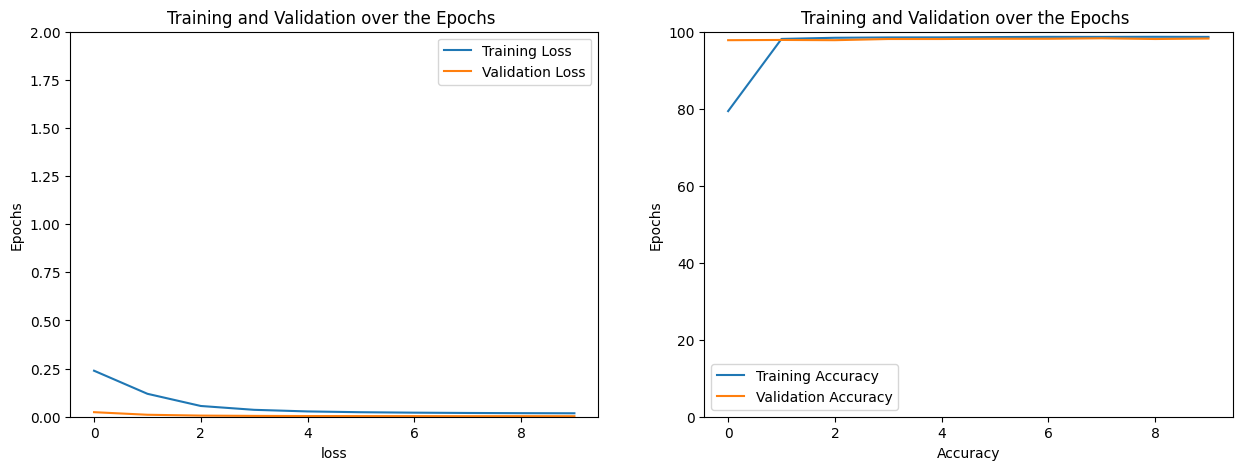

In [90]:
fig,axs = plt.subplots(nrows = 1 , ncols =2 , figsize=(15,5))
axs[0].plot(total_loss_train_plot , label = "Training Loss")
axs[0].plot(total_loss_validation_plot,label ="Validation Loss")
axs[0].set_title("Training and Validation over the Epochs ")
axs[0].set_ylabel("Epochs")
axs[0].set_xlabel("loss")
axs[0].set_ylim([0,2])
axs[0].legend()

axs[1].plot(total_acc_train_plot , label = "Training Accuracy")
axs[1].plot(total_acc_validation_plot,label ="Validation Accuracy")
axs[1].set_title("Training and Validation over the Epochs ")
axs[1].set_ylabel("Epochs")
axs[1].set_xlabel("Accuracy")
axs[1].set_ylim([0,100])
axs[1].legend()

plt.show()